In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import kaleido

plt.style.use("ggplot")

%matplotlib inline

In [3]:
fund_master = pd.read_csv("../data/processed/fund_master_cleaned.csv")

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

aum = pd.read_csv("../data/processed/aum_cleaned.csv")

sip = pd.read_csv("../data/processed/monthly_sip_inflows_cleaned.csv")

category = pd.read_csv("../data/processed/category_inflows_cleaned.csv")

folio = pd.read_csv("../data/processed/industry_folio_count_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

portfolio = pd.read_csv("../data/processed/portfolio_holdings_cleaned.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_cleaned.csv")

In [4]:
print(fund_master.shape)
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(category.shape)
print(folio.shape)
print(performance.shape)
print(transactions.shape)
print(portfolio.shape)
print(benchmark.shape)

(40, 15)
(46000, 3)
(90, 5)
(48, 6)
(144, 3)
(21, 6)
(40, 19)
(32778, 13)
(322, 8)
(8050, 3)


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_plot.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [7]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022–2026)"
)

# Highlight Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=700
)

fig.show()
#fig.write_image("../reports/charts/nav_trend.png")

### Insight 1

The NAV of most mutual fund schemes showed a strong upward trend during 2023, indicating a broad market bull run. During 2024, several schemes experienced slower growth and temporary declines, reflecting periods of market correction.

In [8]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [9]:
aum_filtered = aum[
    (aum["year"] >= 2022) &
    (aum["year"] <= 2025)
]

aum_filtered.head()


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


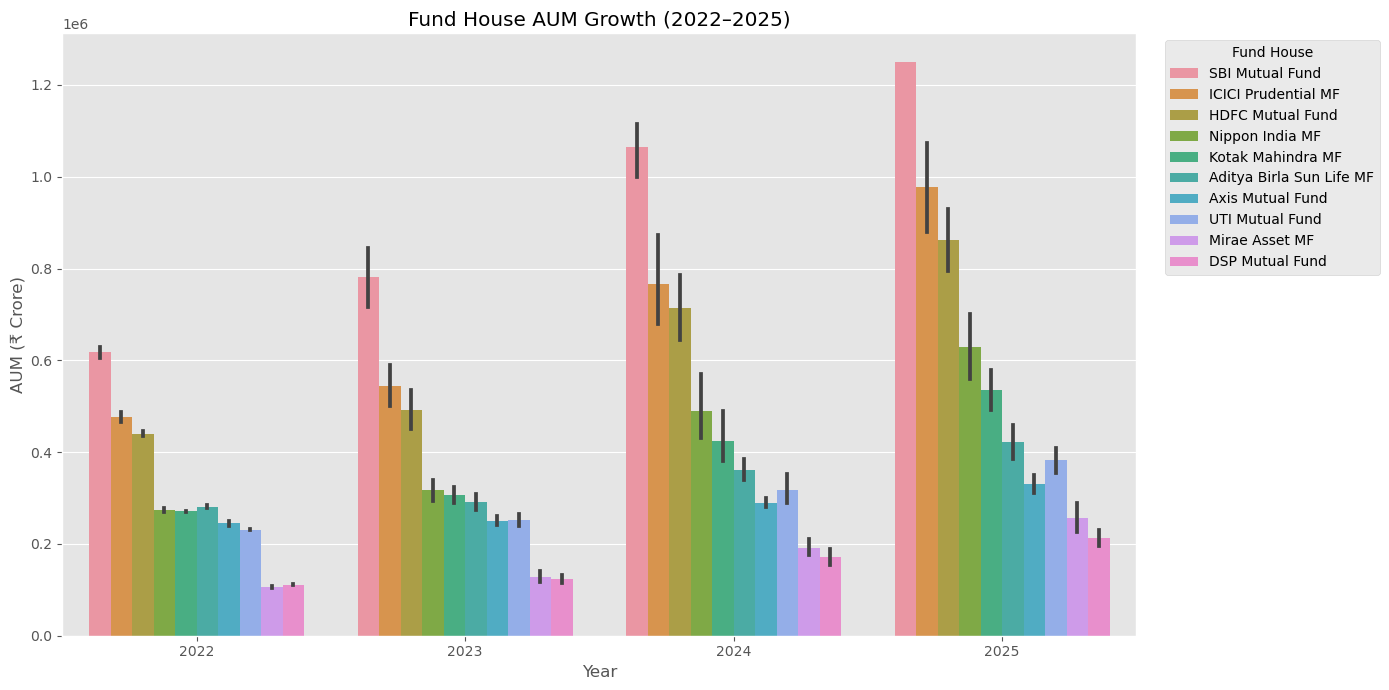

In [10]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_filtered,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("Fund House AUM Growth (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=0)

plt.legend(title="Fund House", bbox_to_anchor=(1.02,1))

plt.tight_layout()
plt.savefig("../reports/charts/aum_growth.png", dpi=300)

plt.show()

### Insight 2

Assets Under Management (AUM) increased steadily across major fund houses from 2022 to 2025. SBI Mutual Fund consistently maintained one of the highest AUM values, demonstrating its dominant position in the mutual fund industry.

In [11]:
sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [12]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    markers=True
)

# Find highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f'Highest: ₹{max_row["sip_inflow_crore"]:.0f} Cr',
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    width=1200,
    height=600
)

fig.show()

### Insight 3

Monthly SIP inflows showed a consistent upward trend from 2022 to 2025. The highest SIP inflow was recorded in December 2025, indicating strong retail investor participation in mutual funds.

In [13]:
category["month"] = pd.to_datetime(category["month"])

category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [14]:
category["Month"] = category["month"].dt.strftime("%b-%Y")

category.head()

,month,category,net_inflow_crore,Month
0,2024-04-01,Large Cap,2413.0,Apr-2024
1,2024-04-01,Mid Cap,3897.0,Apr-2024
2,2024-04-01,Small Cap,3533.0,Apr-2024
3,2024-04-01,Flexi Cap,4947.0,Apr-2024
4,2024-04-01,Large & Mid Cap,4214.0,Apr-2024


In [15]:
heatmap_data = category.pivot_table(
    index="category",
    columns="Month",
    values="net_inflow_crore",
    aggfunc="sum"
)

heatmap_data

Month,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0
Large Cap,2413.0,1940.0,1923.0,1925.0,2025.0,2574.0,2519.0,2234.0,2076.0,1870.0,2255.0,1879.0
Liquid,37537.0,41952.0,34933.0,32374.0,33892.0,34643.0,40486.0,38681.0,41872.0,40506.0,39091.0,35308.0
Mid Cap,3897.0,3899.0,5023.0,4819.0,4316.0,4548.0,5047.0,5061.0,5300.0,4336.0,4106.0,4960.0
Sectoral/Thematic,8052.0,8360.0,9820.0,9215.0,7893.0,9896.0,10030.0,8614.0,8354.0,7397.0,7680.0,8518.0


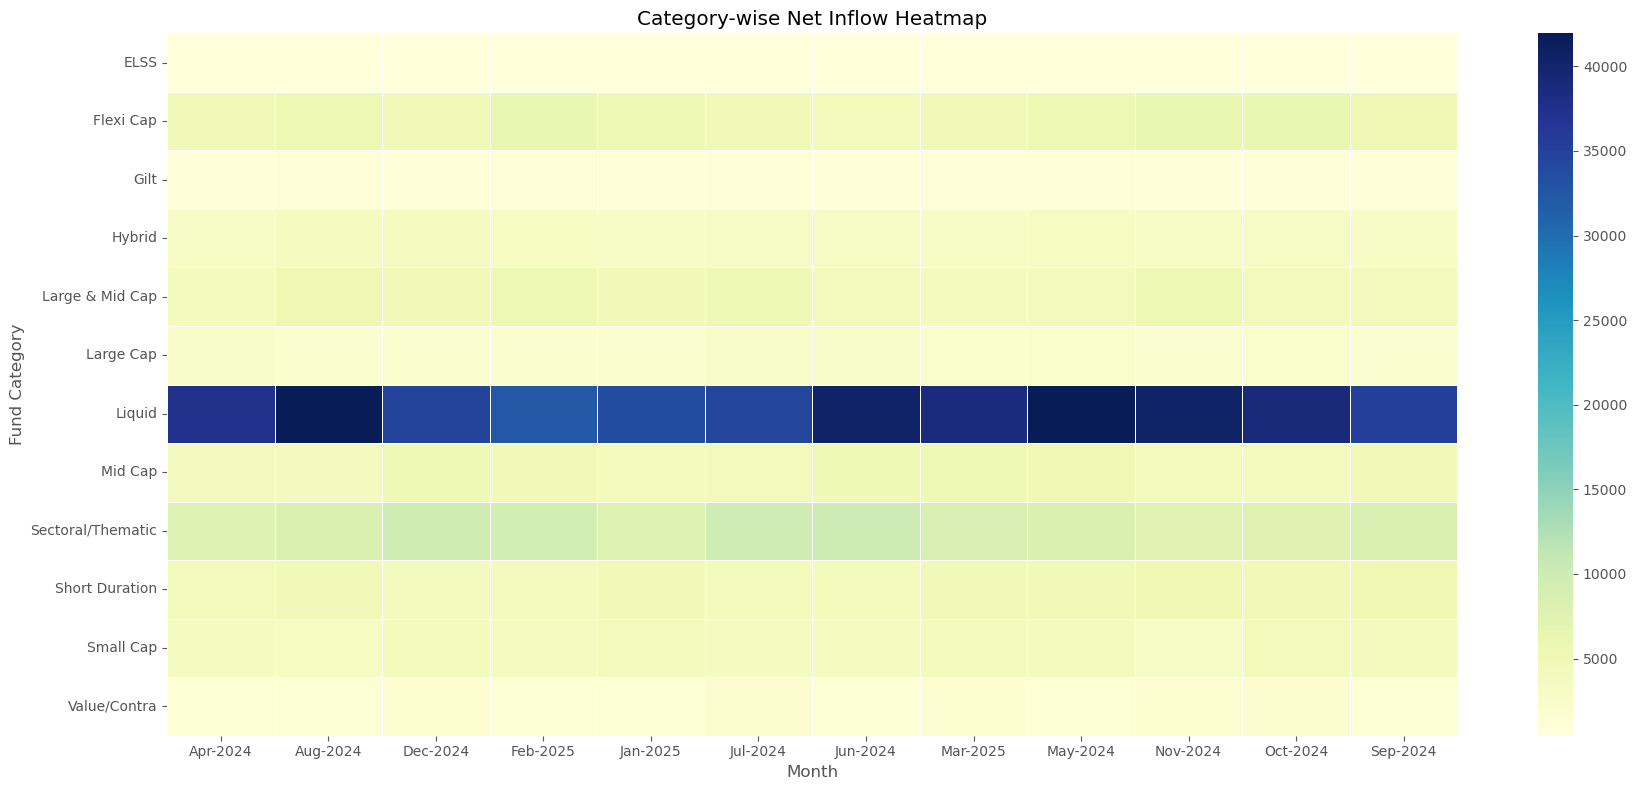

In [16]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

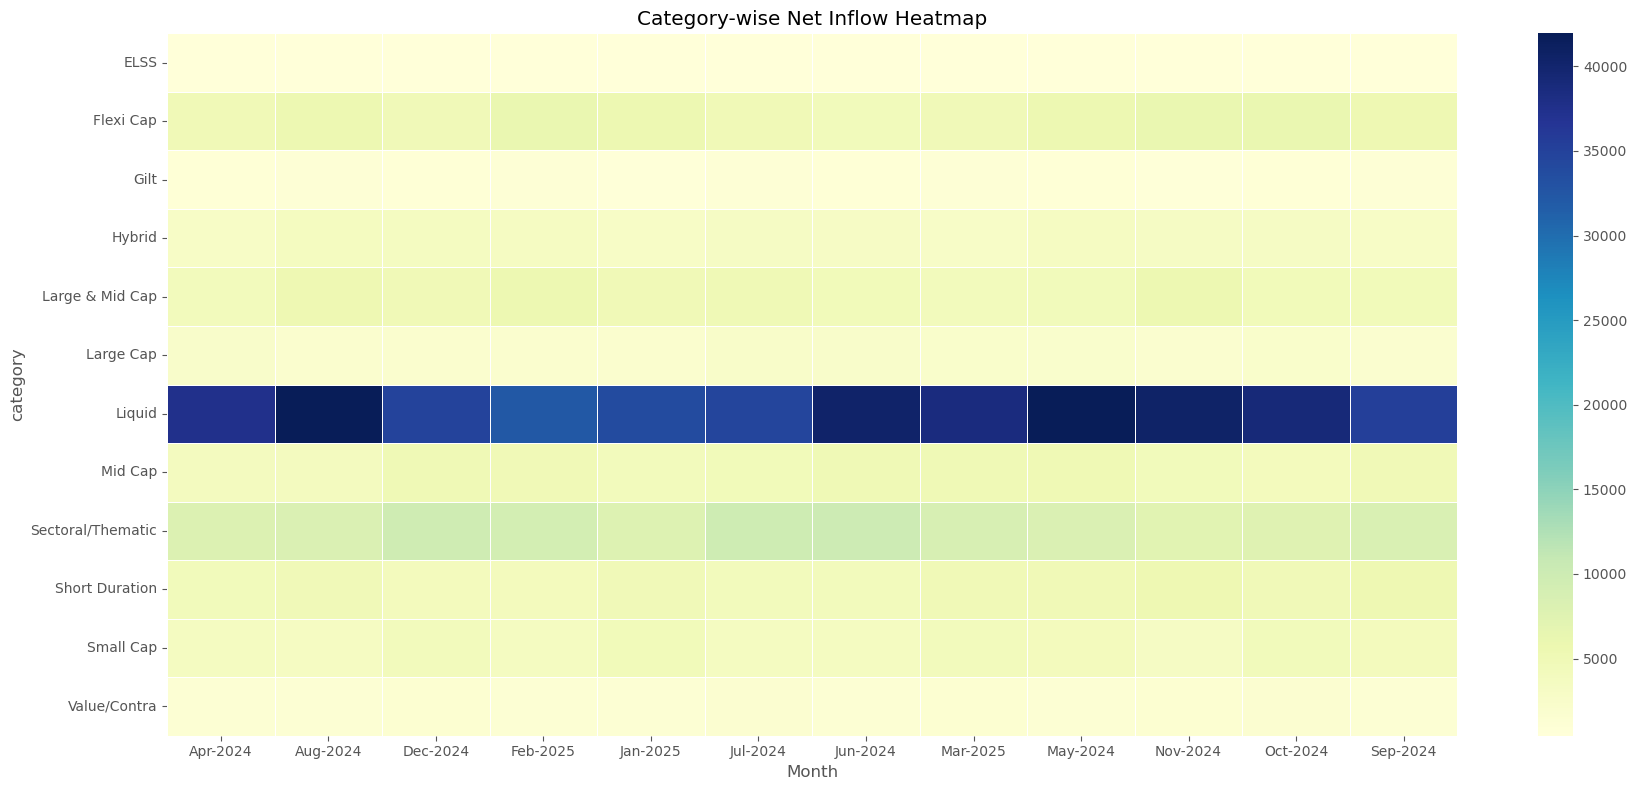

In [17]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")

plt.tight_layout()

plt.savefig("../reports/charts/category_inflow_heatmap.png")

plt.show()

### Insight 4

The heatmap highlights how net inflows varied across mutual fund categories over time. Equity-oriented categories generally attracted stronger inflows, while some categories experienced lower or negative inflows during specific months.

In [18]:
import plotly
print(plotly.__version__)

6.9.0


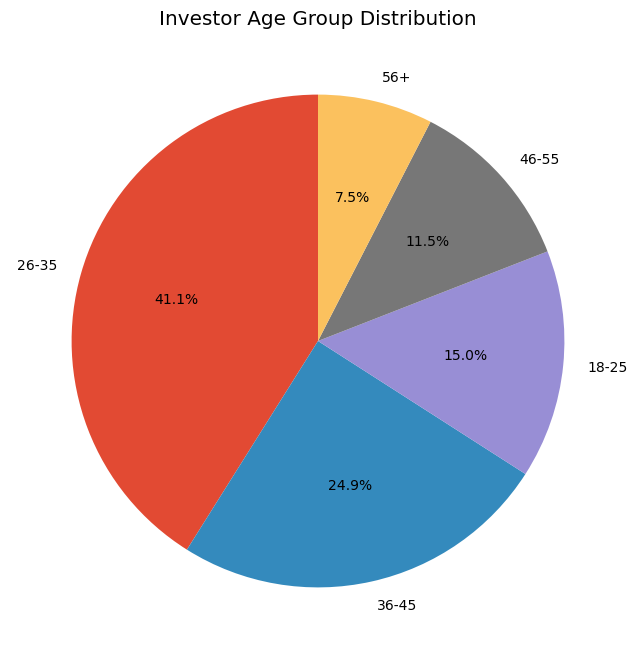

In [19]:
#Age Group Distribution (Pie Chart)
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.savefig("../reports/charts/age_distribution.png", dpi=300)

plt.show()

### Insight 5

Most investors belong to the middle-age groups, indicating that working professionals form the largest segment of mutual fund investors.

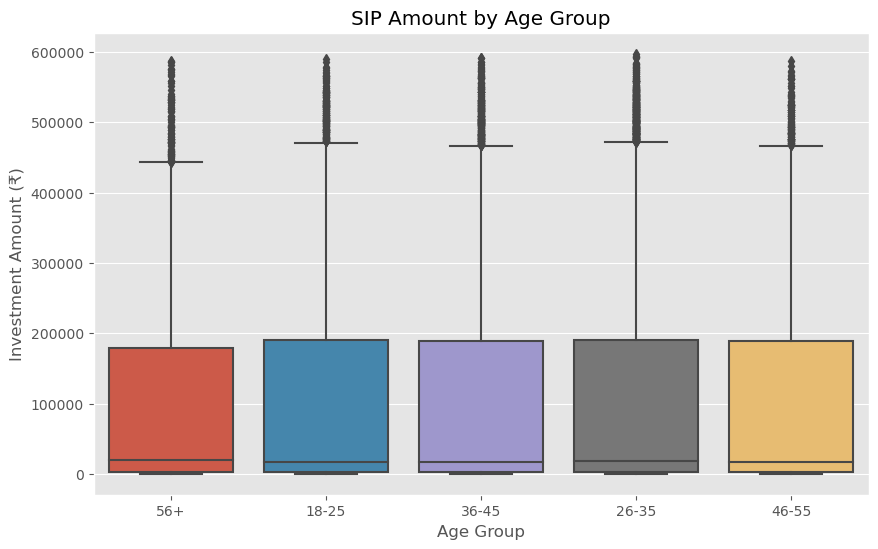

In [20]:
#SIP Amount by Age Group (Box Plot)
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.savefig("../reports/charts/sip_boxplot.png", dpi=300)

plt.show()

### Insight 6

The SIP investment amount varies across age groups, with some groups showing higher median investment values and greater variability.

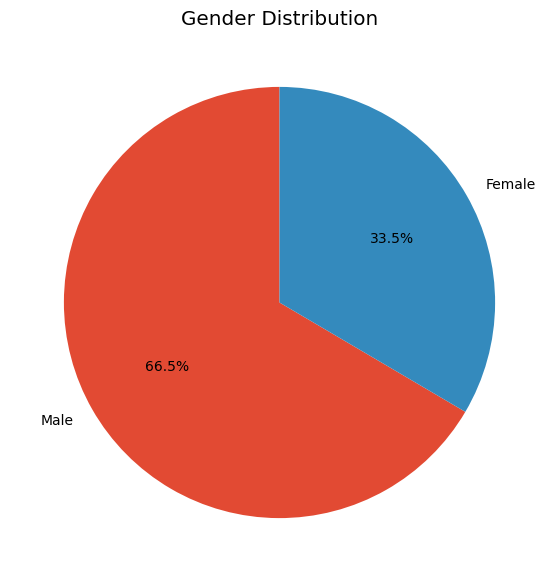

In [21]:
#Gender Split (Pie Chart)
plt.figure(figsize=(7,7))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.savefig("../reports/charts/gender_split.png", dpi=300)

plt.show()

### Insight 7

The gender distribution provides an overview of investor participation across male and female investors in mutual fund investments.

In [22]:
state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip.head()

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
Name: amount_inr, dtype: int64

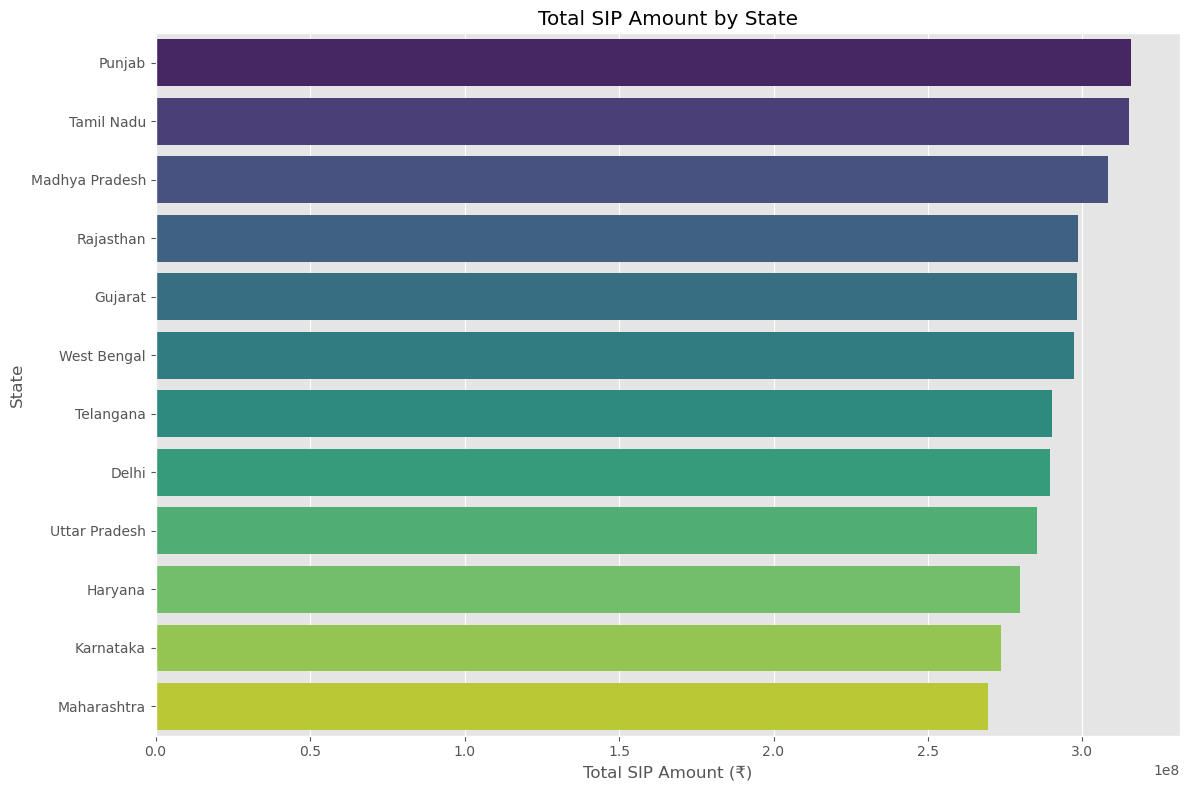

In [23]:
#SIP Amount by State (Horizontal Bar Chart)
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index,
    palette="viridis"
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("../reports/charts/state_distribution.png", dpi=300)

plt.show()

### Insight 8

The state-wise distribution shows that a few states contribute a major share of SIP investments, reflecting higher mutual fund participation in those regions.

In [24]:
city_tier = transactions["city_tier"].value_counts()

city_tier

T30    21719
B30    11059
Name: city_tier, dtype: int64

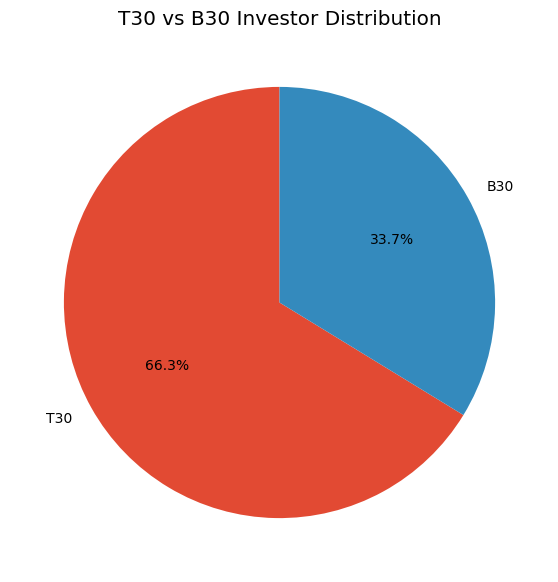

In [25]:
plt.figure(figsize=(7,7))

city_tier.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")
plt.ylabel("")

plt.savefig("../reports/charts/city_tier.png", dpi=300)

plt.show()

### Insight 9

The majority of investors belong to T30 cities, while B30 cities continue to contribute a growing share of mutual fund investments.

In [26]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


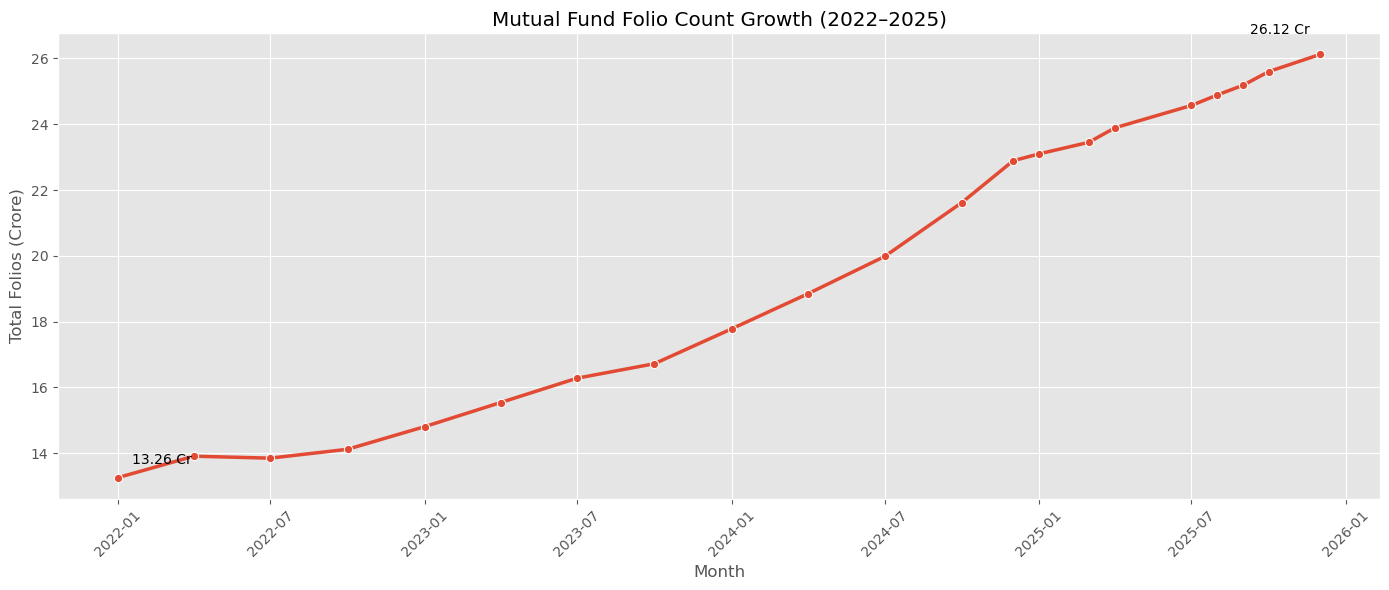

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(14,6))

sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore",
    marker="o",
    linewidth=2.5
)

# Starting point annotation
plt.annotate(
    "13.26 Cr",
    xy=(folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"]),
    xytext=(10,10),
    textcoords="offset points",
    fontsize=10
)

# Ending point annotation
plt.annotate(
    "26.12 Cr",
    xy=(folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"]),
    xytext=(-50,15),
    textcoords="offset points",
    fontsize=10
)

plt.title("Mutual Fund Folio Count Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/charts/folio_growth.png", dpi=300)

plt.show()

### Insight 10

The total mutual fund folio count increased steadily from **13.26 crore** in January 2022 to approximately **26.12 crore** by December 2025, reflecting significant growth in retail investor participation.

In [28]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [29]:
nav["date"] = pd.to_datetime(nav["date"])

In [30]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [31]:
scheme_lookup = performance[["amfi_code", "scheme_name"]].drop_duplicates()

In [32]:
nav_merge = nav.merge(
    scheme_lookup,
    on="amfi_code",
    how="left"
)

nav_merge.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [33]:
selected_funds = nav_merge["scheme_name"].drop_duplicates().head(10)

nav10 = nav_merge[
    nav_merge["scheme_name"].isin(selected_funds)
]

In [34]:
pivot_nav = nav10.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

In [35]:
daily_returns = pivot_nav.pct_change().dropna()

In [36]:
corr_matrix = daily_returns.corr()

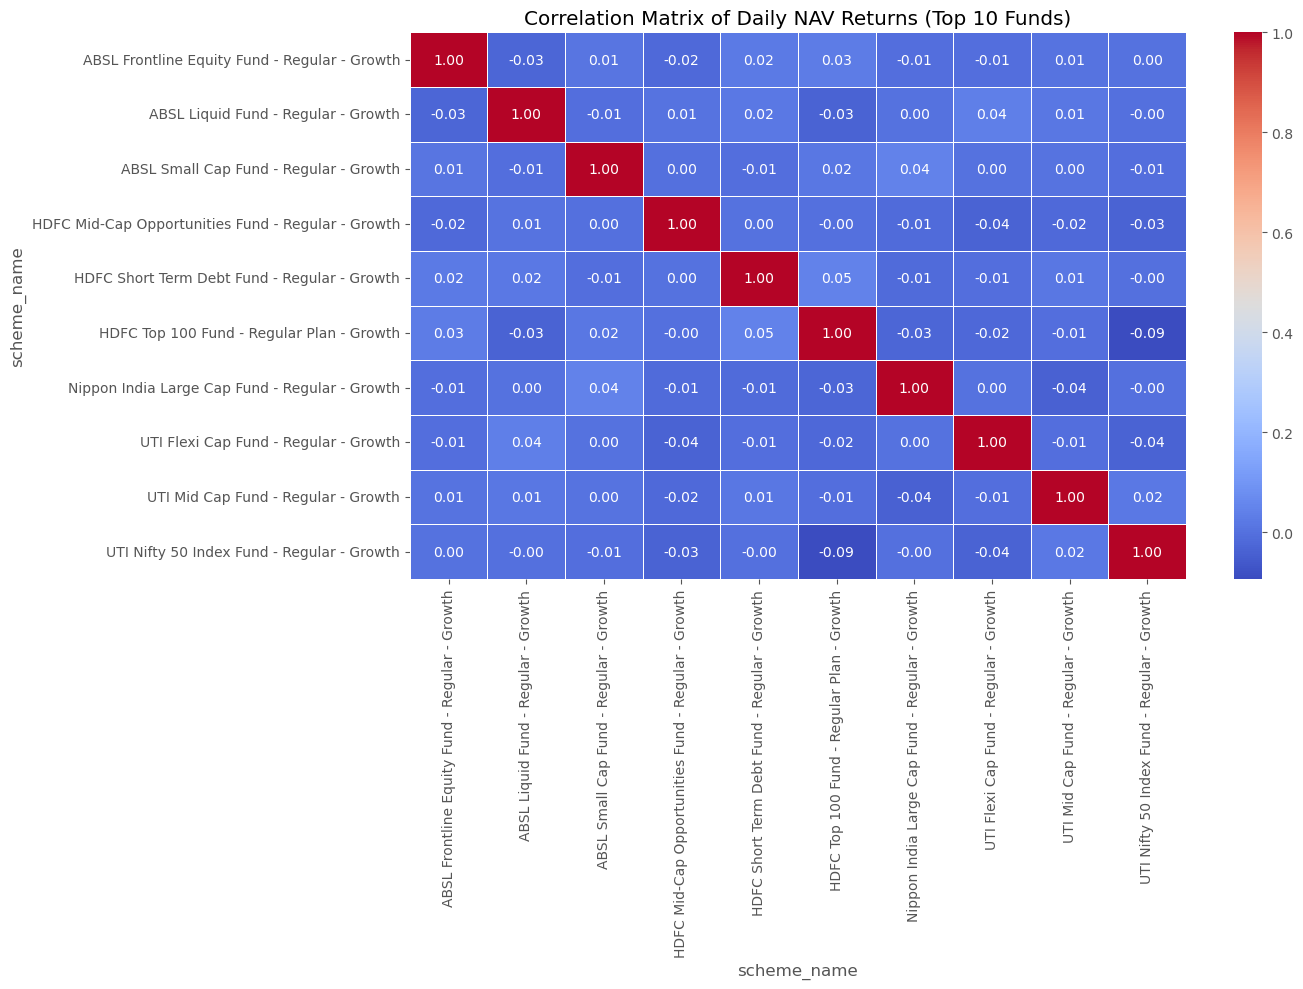

In [37]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns (Top 10 Funds)")

plt.tight_layout()

plt.savefig("../reports/charts/nav_correlation_matrix.png", dpi=300)

plt.show()

### Insight 11

The correlation matrix shows that most selected mutual funds have a strong positive correlation in their daily NAV returns. This suggests that funds within similar categories tend to move together in response to overall market conditions, while a few funds exhibit lower correlations due to differences in investment strategies.

In [38]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [39]:
sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

sector_data

,sector,weight_pct
0,Automobile,323.65
1,Banking,652.26
2,Cement,105.03
3,Consumer Goods,127.61
4,Diversified,169.23
5,Energy,117.91
6,FMCG,229.11
7,IT,455.47
8,Infrastructure,192.16
9,NBFC,119.09


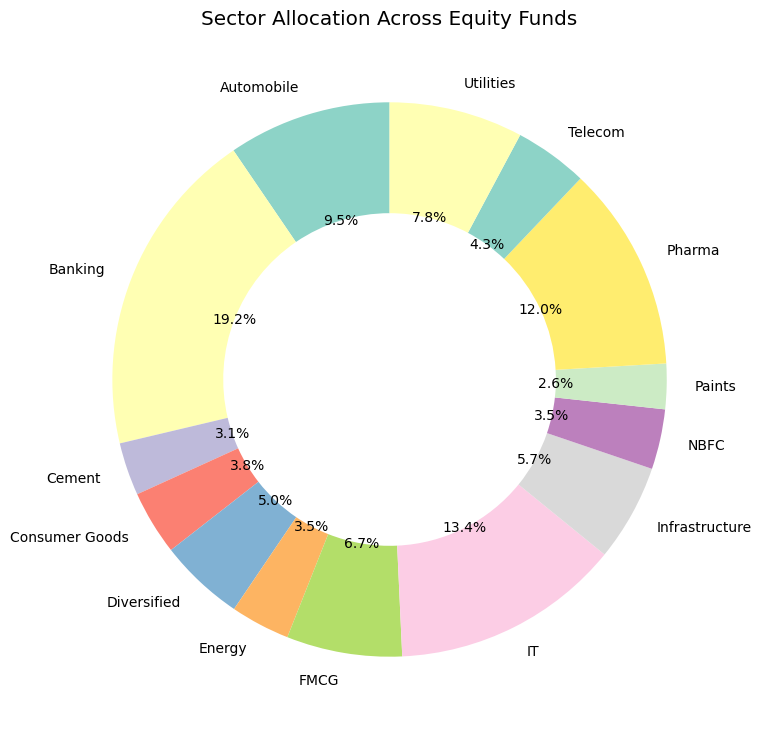

In [40]:
plt.figure(figsize=(9,9))

colors = sns.color_palette("Set3", len(sector_data))

plt.pie(
    sector_data["weight_pct"],
    labels=sector_data["sector"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig("../reports/charts/sector_allocation_donut.png", dpi=300)

plt.show()

### Insight 12

The sector allocation chart shows that investments are concentrated in a few major sectors, indicating diversified exposure while maintaining higher allocation to sectors with strong growth potential.

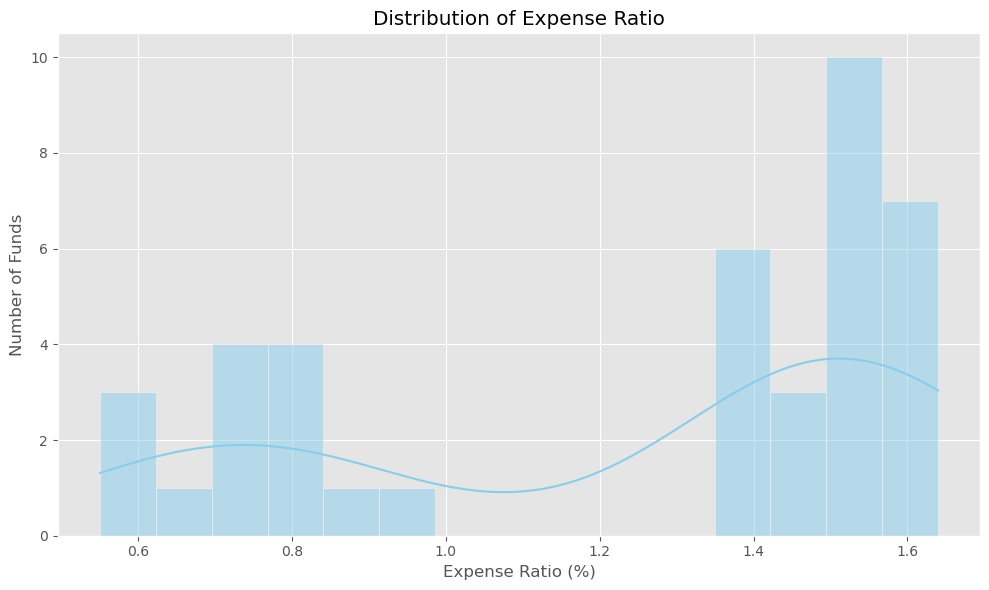

In [41]:
#Expense Ratio Distribution (Histogram)
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Expense Ratio")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig("../reports/charts/expense_ratio_distribution.png", dpi=300)

plt.show()

### Insight 13

Most mutual funds have expense ratios between 0.5% and 1.5%, indicating that the majority of schemes maintain moderate fund management costs.

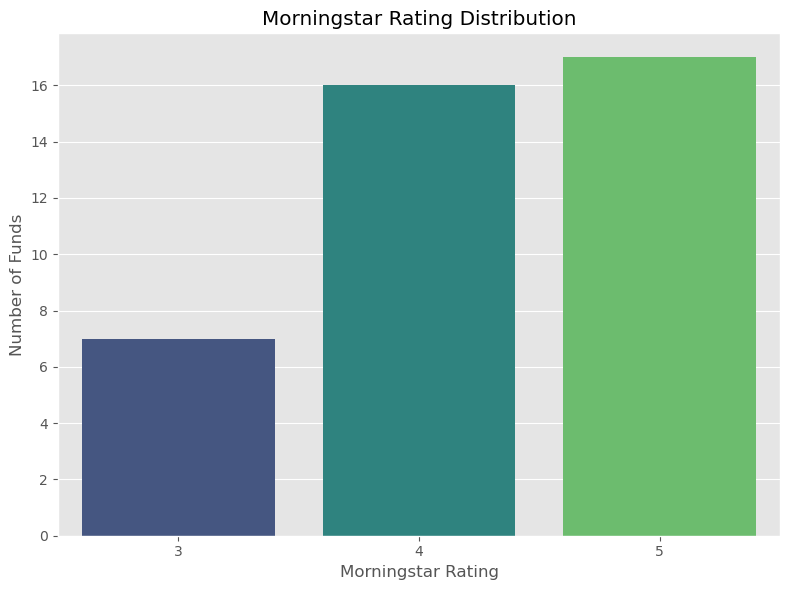

In [42]:
#Morningstar Rating Distribution
plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x="morningstar_rating",
    palette="viridis"
)

plt.title("Morningstar Rating Distribution")
plt.xlabel("Morningstar Rating")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig("../reports/charts/morningstar_rating_distribution.png", dpi=300)

plt.show()

### Insight 14

Most schemes are concentrated around mid-to-high Morningstar ratings, indicating generally good historical performance across the selected mutual funds.

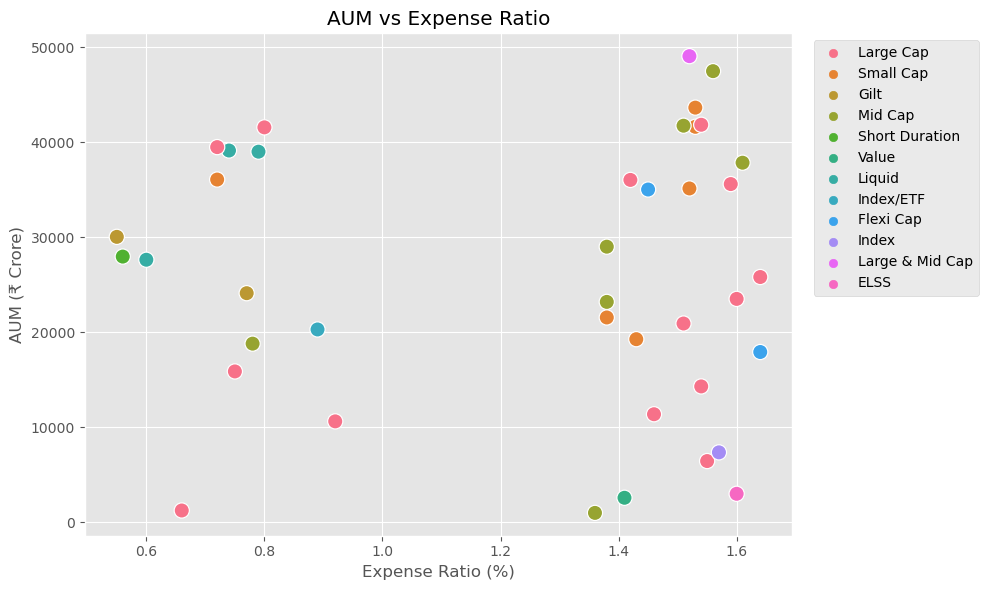

In [43]:
#AUM vs Expense Ratio (Scatter Plot)
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="expense_ratio_pct",
    y="aum_crore",
    hue="category",
    s=120
)

plt.title("AUM vs Expense Ratio")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("AUM (₹ Crore)")

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.savefig("../reports/charts/aum_vs_expense_ratio.png", dpi=300)

plt.show()

### Insight 15

Large AUM funds generally maintain competitive expense ratios, while smaller funds exhibit greater variation in their fee structures.

# Final EDA Summary

## Key Findings

1. Daily NAV values showed a consistent upward trend across most mutual fund schemes between 2022 and 2025, reflecting long-term market growth.

2. SBI Mutual Fund maintained the highest Assets Under Management (AUM), demonstrating its strong market leadership.

3. Monthly SIP inflows steadily increased over the years, reaching an all-time high of ₹31,002 crore in December 2025.

4. Equity-oriented fund categories consistently attracted the highest investor inflows.

5. The majority of investors belong to middle-age groups, indicating higher participation from working professionals.

6. SIP investment amounts vary across different age groups, with some investors contributing significantly larger amounts.

7. Investor participation is relatively balanced across genders, with slight differences in distribution.

8. T30 cities contribute a larger share of investments compared to B30 cities, while B30 participation continues to grow.

9. Mutual fund folio count increased from approximately **13.26 crore** to **26.12 crore**, indicating strong retail investor growth.

10. Most equity mutual funds exhibit strong positive correlation in daily NAV returns, suggesting similar market movement.

11. Portfolio allocation is concentrated in major sectors such as Financial Services, Information Technology, and Banking.

12. Most mutual funds maintain expense ratios below 1.5%, indicating competitive fund management costs.

13. Higher-rated Morningstar funds represent a significant portion of the analysed schemes.

14. Larger AUM funds generally maintain lower expense ratios than smaller funds.

15. Overall, the Indian mutual fund industry demonstrated strong growth in investor participation, assets under management, and systematic investments during 2022–2025.